# Full Powered Gradient Boost
**Author:** Thom Daniel C. Yutuc

In this module we will be creating a ***"Fully Powered"*** Gradient Boosting model with the following add ons:
1. Parameter Autotuning
    - Grid Search
    - Cross-Validation
2. Solid Parameter Grid

We will be using the **US Adult Census Dataset**. Exploratory Data Analysis (EDA) was skipped for a much cleaner notebook, but it is worth noting that the dataset contains a significant amount of **class imbalances** and **outliers**.

**Note:** "Fully Powered" in terms of what a laptop can handle so something like nested cross-validations, ensemble stacking, and other computationally costly methods will not be performed

## Loading the Dataset and Data Preparation

In [19]:
# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# Load dataset and check size
data = fetch_openml(data_id=43436, as_frame=True)
df = data.frame
print(f"Data loaded successfully, Dataset Size: {len(df)} rows")

Data loaded successfully, Dataset Size: 32561 rows


In [3]:
# Dropped null values
df_clean = df.dropna()

In [4]:
# Create boolean masks for target variable
df_clean["income_binary"] = (df_clean["income"] == "50K").astype(int)

# Check target class balance
print(df_clean["income_binary"].value_counts())
print(df_clean["income_binary"].value_counts(normalize=True))

income_binary
0    22654
1     7508
Name: count, dtype: int64
income_binary
0    0.751078
1    0.248922
Name: proportion, dtype: float64


In [5]:
# Create dummies
categorical_cols = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]

df_categ = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

In [6]:
# Drop duplicate column
df_categ = df_categ.drop(columns=['income'])

In [7]:
# Fix column name format
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)
df_categ.columns = df_categ.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)

In [8]:
# Make data types consistent on all columns
df_categ_final = df_categ.astype(float)
df_categ_final

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_binary,workclass_Local_gov,workclass_Private,workclass_Self_emp_inc,...,native_country_Portugal,native_country_Puerto_Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_TrinadadTobago,native_country_United_States,native_country_Vietnam,native_country_Yugoslavia
1,82.0,132870.0,9.0,0.0,4356.0,18.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,54.0,140359.0,4.0,0.0,3900.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41.0,264663.0,10.0,0.0,3900.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,34.0,216864.0,9.0,0.0,3770.0,45.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,38.0,150601.0,6.0,0.0,3770.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22.0,310152.0,10.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32557,27.0,257302.0,12.0,0.0,0.0,38.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32558,40.0,154374.0,9.0,0.0,0.0,40.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32559,58.0,151910.0,9.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Train-Test Split

In [9]:
# Seperate target and features
X = df_categ_final.loc[:, df_categ_final.columns != 'income_binary'].copy()
y = df_categ_final['income_binary'].copy()

# Create train-test split with stratification for consistency across y distributions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Model Creation

### Concept Notes
**1. Grid Search**  
A brute force algorithm that searches through all specified combinations of hyperparameters to find the optimal configuration.

**2. Cross-Validation**  
The dataset is split into *k* folds. The model is trained on *k-1* folds and validated on the remaining fold, repeating the process *k* times. The average performance across all folds is used to evaluate the model.

### Parameter Grid Notes
**3. n_estimators**  
The number of boosting stages (trees) to perform.  
- **Higher values:** Increased stability, better performance, higher computational cost  
- **Lower values:** Risk underfitting, faster training

**4. max_depth**  
The maximum depth of each individual tree.  
- **Deeper trees:** Capture complex interactions, risk overfitting  
- **Shallower trees:** Simpler model, risk underfitting

**5. learning_rate**  
Shrinks the contribution of each tree by the specified factor.  
- **Lower values (0.01-0.05):** More stable training, requires more n_estimators  
- **Higher values (0.1-0.3):** Faster convergence, risk overfitting  
- **Typical range:** 0.01 to 0.3

**6. subsample**  
The fraction of samples to use for fitting each individual tree.  
- **Lower values (0.7-0.8):** Increases randomness, reduces overfitting, slower convergence  
- **Higher values (0.9-1.0):** More stable, faster convergence, risk overfitting  
- **Stochastic Gradient Boosting:** Using subsample < 1.0 introduces randomness for better generalization

**7. min_samples_split**  
The minimum number of samples required to split an internal node.  
- **Higher values:** Prevents overfitting, creates simpler trees  
- **Lower values:** Allows more complex trees, risk overfitting  
- **Typical range:** 2 to 10

**8. min_samples_leaf**  
The minimum number of samples required to be at a leaf node.  
- **Higher values:** Smoother predictions, reduces overfitting  
- **Lower values:** Captures more patterns, risk overfitting  
- **Typical range:** 1 to 4

**9. max_features**  
The number of features to consider when looking for the best split.  
- **'sqrt':** Uses sqrt(n_features) (recommended for classification)  
- **'log2':** Uses log2(n_features)  
- **None:** Uses all features (increases computation, risk overfitting)  
- **Lower values:** Increases randomness, reduces overfitting

**10. n_jobs**  
Controls the number of CPU cores used for parallel processing during grid search.  
- **n_jobs = -1:** Uses all available CPU cores (fastest training)  
- **n_jobs = 1:** Uses single core (slowest, default)  
- **n_jobs = 2, 4, 8:** Uses specified number of cores  
- **n_jobs = -2:** Uses all cores except one

**11. return_train_score**  
Controls whether training scores are computed and included in cv_results_.  
- **return_train_score = True:** Returns both train and validation scores (helps detect overfitting)  
- **return_train_score = False:** Returns only validation scores (faster computation)  
- **Default:** False (deprecated) or True in newer versions

**12. verbose**  
Controls the amount of output/logging displayed during grid search.  
- **verbose = 0:** Silent mode (no output)  
- **verbose = 1:** Progress bar and basic information  
- **verbose = 2:** Detailed output (all parameter combinations and scores)  
- **verbose = 3:** Maximum detail (useful for debugging)

### Coding Notes
**1. best_estimator_**  
The model with the best hyperparameters found by grid search (the actual fitted model you use for predictions).

**2. best_score_**  
The mean cross-validation score (accuracy, R², etc.) of the best estimator.

**3. cv_results_**  
Dictionary containing all evaluation results from each parameter combination (includes mean_train_score, mean_test_score, std_test_score, rank_test_score, param_* columns, etc.).

**4. best_index_**  
The index position in cv_results_ that corresponds to the best estimator.

In [16]:
# Gradient Boosting (Most Common/Default Parameters)
base_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42).fit(X_train, y_train)

y_pred = base_gb.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred)

print(f"Base GB Train Accuracy: {train_accuracy:.4f}")

Base GB Train Accuracy: 0.8637


In [27]:
# ----------------------------------------------
# GRADIENT BOOSTING WITH HYPERPARAMETER TUNING
# ----------------------------------------------
gb = GradientBoostingClassifier(random_state=42)

# Hyperparameter grid
gb_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ['sqrt', None]
}

# Grid search with cross-validation
gb_grid = GridSearchCV(gb, gb_params, cv=5, n_jobs=-1, 
                       return_train_score=True, verbose=1).fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
best_idx = gb_grid.best_index_

print("\n" + "="*70)
print("GRADIENT BOOSTING - TUNING RESULTS")
print("="*70)

# ----------------------------------------------
# 1. BEST MODEL RESULTS
# ----------------------------------------------
print("\nBEST MODEL CONFIGURATION")
print(f"Parameters: {gb_grid.best_params_}")
print(f"CV Score: {gb_grid.best_score_:.4f} (±{gb_grid.cv_results_['std_test_score'][best_idx]:.4f})")

# ----------------------------------------------
# 2. TOP 5 MODELS
# ----------------------------------------------
print("\nTOP 5 MODELS BY CV SCORE")
results_df = pd.DataFrame(gb_grid.cv_results_)
top_indices = np.argsort(results_df['mean_test_score'])[-5:][::-1]

for rank, idx in enumerate(top_indices, 1):
    params = results_df['params'][idx]
    mean_score = results_df['mean_test_score'][idx]
    std_score = results_df['std_test_score'][idx]
    print(f"\n{rank}. Score: {mean_score:.4f} (±{std_score:.4f})")
    
    # Simplify parameter display (show only key differences)
    simple_params = {k: v for k, v in params.items() if k in ['n_estimators', 'max_depth', 'learning_rate']}
    print(f"{simple_params}")

# ----------------------------------------------
# 3. OVERFITTING ANALYSIS
# ----------------------------------------------
print("\nOVERFITTING ANALYSIS")

if 'mean_train_score' in gb_grid.cv_results_:
    train_score = gb_grid.cv_results_['mean_train_score'][best_idx]
    val_score = gb_grid.best_score_
    gap = train_score - val_score
    print(f"Training CV Score:   {train_score:.4f}")
    print(f"Validation CV Score: {val_score:.4f}")
    print(f"Train-Val Gap:       {gap:.4f}")
    
    # Simplified interpretation
    if gap < 0.03:
        print(f"Good generalization")
    elif gap < 0.07:
        print(f"Some overfitting")
    else:
        print(f"Significant overfitting")
else:
    print("Training scores not available")

print("="*70)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits

GRADIENT BOOSTING - TUNING RESULTS

BEST MODEL CONFIGURATION
Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.9}
CV Score: 0.8671 (±0.0058)

TOP 5 MODELS BY CV SCORE

1. Score: 0.8671 (±0.0058)
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

2. Score: 0.8671 (±0.0060)
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

3. Score: 0.8671 (±0.0053)
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

4. Score: 0.8669 (±0.0058)
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

5. Score: 0.8668 (±0.0052)
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

OVERFITTING ANALYSIS
Training CV Score:   0.8859
Validation CV Score: 0.8671
Train-Val Gap:       0.0188
Good generalization


*Note:* Running this cells took 156 seconds

## Evaluation Metrics


PERFORMANCE METRICS
Accuracy: 0.8744
Precision: 0.8005
Recall: 0.6598
F1-Score: 0.7234

Confusion Matrix Breakdown:
True Positives (TP): 991
True Negatives (TN): 4284
False Positives (FP): 247
False Negatives (FN): 511

Error Analysis:
Type I Error Rate: 0.0545 (5.45%)
Type II Error Rate: 0.3402 (34.02%)
Total Errors: 758 / 6033 (12.56%)


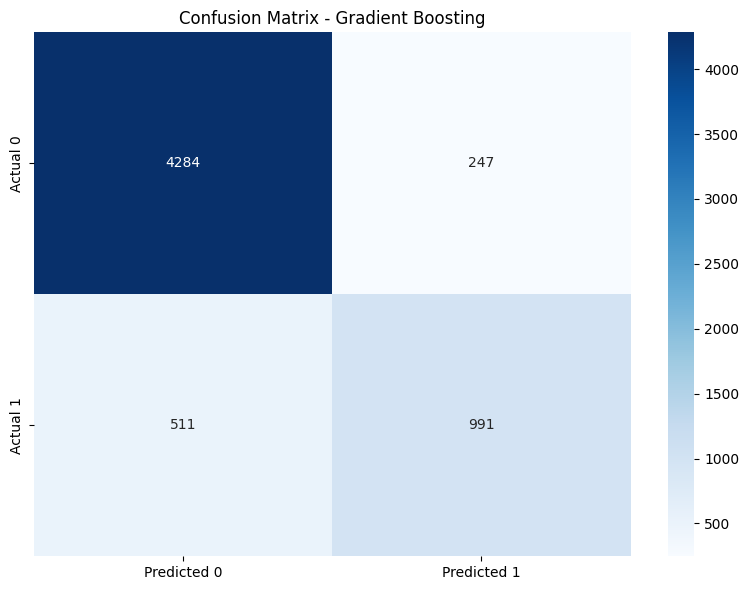

In [26]:
# Test Predictions
y_pred = best_gb.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Error rates
type1_rate = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
type2_rate = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate

# Display metrics
print("\n" + "="*50)
print("PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print(f"\nConfusion Matrix Breakdown:")
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

print(f"\nError Analysis:")
print(f"Type I Error Rate: {type1_rate:.4f} ({(type1_rate * 100):.2f}%)")
print(f"Type II Error Rate: {type2_rate:.4f} ({(type2_rate * 100):.2f}%)")
print(f"Total Errors: {fp + fn} / {len(y_test)} ({(((fp + fn) / len(y_test)) * 100):.2f}%)")

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.tight_layout()
plt.show()

### Model Generalization
- The validation score and test accuracy are not far apart, indicating the model generalizes well with minimal overfitting

### Error Analysis
- The model minimizes **false positives** (5.45%) more than **false negatives** (34.02%)
- This suggests the model is conservative as it prefers to predict "negative" unless confident about "positive"
- Depending on the use case, this bias may be desirable (e.g., avoiding false alarms) or may need adjustment (e.g., if missing positives is costly)

### Overall Performance
- Total error rate is **12.56%**, with the majority of errors coming from false negatives
- Precision (**0.8005**) is notably higher than recall (**0.6598**), confirming the model's conservative prediction behavior
- The F1-score (**0.7234**) provides a balanced view of precision-recall trade-off

### Key Takeaway
The model performs well overall with good generalization, but the high Type II error rate suggests room for improvement if capturing more positive cases is a priority.

## Final Notes
- It is generally acceptable to only use **n_estimators**, **max_depth**, and **learning_rate**, as these are the primary hyperparameters. Other parameters are mainly used to reduce overfitting, which is particularly relevant in this case since feature selection was not performed.

- Feature selection is not required for Gradient Boosting as this dataset only contains 97 features. However, when working with datasets containing around 1,000 or more features, feature selection is recommended as simpler models are easier to interpret (though not always guaranteed to perform better).